# CMN Calibration + Temperature Log

Two steps in one notebook, run top to bottom:

1. Fit `T = C / (Q9 - Q0)` from the Cernox_temperature vs CMN_resistance calibration data.
2. Turn `Q9` log into temperature, with uncertainty.

**To add a new reading:** open `time_Q9.csv`, add a row, save, then run this notebook again.

In [1]:
# Settings
FOLDER = r"C:\Users\user\Documents\GitHub\CMN-Temperature-Calibration-and-Sensing" # the folder that stores the log data 

CALIBRATION_CSV = FOLDER + r"\Q9_T.csv"      # Cernox_temperature vs CMN_resistance calibration data
DAILY_CSV       = FOLDER + r"\time_Q9.csv"   # Q9 log 

OUT_PER_READING = FOLDER + r"\temperature_log.csv"
OUT_PLOT        = FOLDER + r"\temperature_log.png"

SIGMA_Q9 = 0.0                # extra Q9 measurement noise, if you know it (mOhm)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## Step 1: Calibration Fit

C  = 0.008837 +/- 0.000747
Q0 = 0.262887 +/- 0.002806


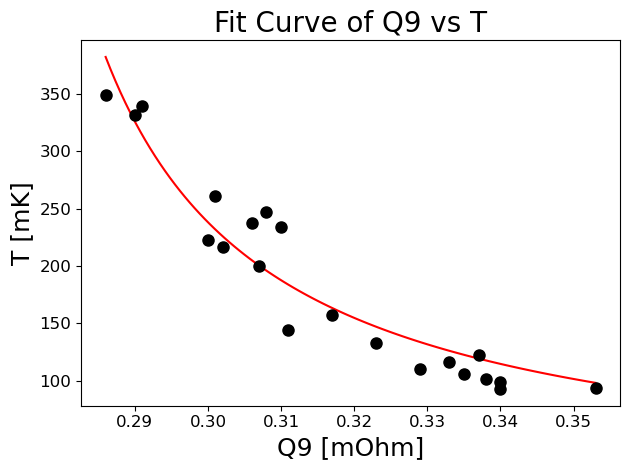

In [3]:
cal = pd.read_csv(CALIBRATION_CSV)
Q9_cal = cal.iloc[:, 0].to_numpy()
T_cal  = cal.iloc[:, 1].to_numpy()

def cmn_model(Q9, C, Q0):
    # T = C / (Q9 - Q0)
    return C / (Q9 - Q0)

Q9_fit, T_fit = Q9_cal, T_cal

# Initial guess using the linear fit results from the linear form: 1/T = Q9/C - Q0/C
a, b = np.polyfit(Q9_fit, 1/T_fit, 1)
popt, pcov = curve_fit(cmn_model, Q9_fit, T_fit, p0=[1 / a, -b / a])
C, Q0 = popt
Q9_min, Q9_max = Q9_fit.min(), Q9_fit.max()

print(f"C  = {C:.6f} +/- {np.sqrt(pcov[0,0]):.6f}")
print(f"Q0 = {Q0:.6f} +/- {np.sqrt(pcov[1,1]):.6f}")

q_line = np.linspace(Q9_min, Q9_max, 100)

plt.plot(q_line, cmn_model(q_line, *popt)*1000, 'r-', lw=1.5)
plt.plot(Q9_cal, T_cal*1000, 'o', markersize=8, color='black')
plt.xlabel('Q9 [mOhm]', fontsize=18)
plt.ylabel('T [mK]', fontsize=18)
plt.title('Fit Curve of Q9 vs T', fontsize=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

## Step 2: Convert Q9 into T with uncertainty

In [4]:
def T_from_Q9(Q9, sigma_Q9=0.0):
    Q9 = np.atleast_1d(np.asarray(Q9, dtype=float))  # scalar -> 1-element array
    T = C / (Q9 - Q0)
    dT_dC = 1 / (Q9 - Q0)
    dT_dQ0 = C / (Q9 - Q0)**2
    var_fit = dT_dC**2 * pcov[0, 0] + dT_dQ0**2 * pcov[1, 1] + 2 * dT_dC * dT_dQ0 * pcov[0, 1]
    var_Q9 = (C / (Q9 - Q0)**2 * sigma_Q9) ** 2
    sigma_T = np.sqrt(var_fit + var_Q9)
    return (T[0], sigma_T[0]) if T.size == 1 else (T, sigma_T)

# Test
T_ex, sT_ex = T_from_Q9(Q9=0.70)
print(f"Q9 = 0.70 mOhm  ->  T = ({T_ex*1000:.2f} +/- {sT_ex*1000:.2f}) mK")

Q9 = 0.70 mOhm  ->  T = (20.22 +/- 1.59) mK


## Step 3: Process Log File

Saved 50 rows to C:\Users\user\Documents\GitHub\CMN-Temperature-Calibration-and-Sensing\temperature_log.csv


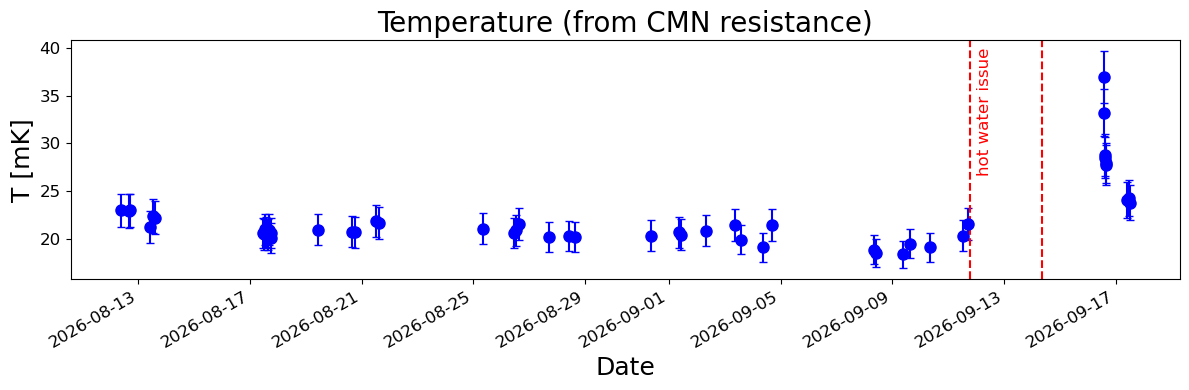

In [5]:
log = pd.read_csv(DAILY_CSV)
DateTime = log.iloc[:, 0].to_numpy()
Q9_col = log.iloc[:, 1].to_numpy()
Q9_name = log.columns[1]

T_all, sT_all = T_from_Q9(Q9_col, sigma_Q9=SIGMA_Q9)
log["T [K]"] = T_all
log["sigma_T [K]"] = sT_all
log["DateTime"] = pd.to_datetime(DateTime)

log.to_csv(OUT_PER_READING, index=False)
print(f"Saved {len(log)} rows to {OUT_PER_READING}")

ERROR_TIME_1a = pd.Timestamp("2026-09-11 18:31:00")
ERROR_TIME_1b = pd.Timestamp("2026-09-14 08:40:00")

fig, ax = plt.subplots(figsize=(12, 4))
ax.errorbar(log["DateTime"], log["T [K]"]*1000, yerr=log["sigma_T [K]"]*1000, fmt='o', color='blue', ms=8, capsize=3)

ax.axvline(ERROR_TIME_1a, color='red', linestyle='--', linewidth=1.5)
ax.annotate("hot water issue", xy=(ERROR_TIME_1a, 1), xycoords=("data", "axes fraction"), xytext=(5, -5), textcoords="offset points", rotation=90, va="top", ha="left", color="red", fontsize=12)
ax.axvline(ERROR_TIME_1b, color='red', linestyle='--', linewidth=1.5)


ax.set_xlabel("Date", fontsize=18)
ax.set_ylabel("T [mK]", fontsize=18)
ax.set_title("Temperature (from CMN resistance)", fontsize=20)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(OUT_PLOT, dpi=600)
plt.show()